## 🏎️ Araba Yarışı

---

Bu projede, Gymnasium'dan [Car Racing ortamı](https://gymnasium.farama.org/environments/box2d/car_racing/) ile çalışacaksınız. Görev, prosedürel olarak oluşturulan bir pistte arabayla sürüş yaparak, yolda kalırken turları verimli bir şekilde tamamlamaktır.

İki tür pekiştirmeli öğrenme ajanı eğiteceksiniz: bir **DQN ajanı** ve bir **PPO ajanı**.

---

### 🚧 Bu Projeyi Farklı Kılan Nedir?

**CliffWalking** gibi **ayrık eylem uzayları** kullanan önceki ortamların aksine, Car Racing ortamı **sürekli eylem uzayı** kullanır.

- Ajanlar şunları kontrol etmeli:
  - **Direksiyon** (sol/sağ)
  - **Hızlanma** (gaz)
  - **Fren yapma**

Bu şu anlama gelir:
- ❌ DQN, ince ayarlı sürekli kontrolde zorlanır  
- ✅ PPO çok daha uygun, çünkü sürekli politikaları doğrudan öğrenebilir

🧠 Bu proje, **Politika Gradyanı yöntemleri** olan PPO'nun neden sürekli kontrol problemlerinde tercih edildiğini ve DQN'u yanlış ortama zorladığınızda ne olduğunu anlamanıza yardımcı olacak.

---
Bu proje için ihtiyaç duyacağımız tüm paketleri içe aktararak başlayalım:

In [8]:
%pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 603.4 kB/s  0:00:03 eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1
Note: you may need to restart the kernel to use updated packages.


In [9]:
%pip install "gymnasium[box2d]" "stable-baselines3>=2.0.0" shimmy

  Using cached stable_baselines3-2.8.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached shimmy-2.0.1-py3-none-any.whl.metadata (4.4 kB)
  Using cached gymnasium-1.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached farama_notifications-0.0.6-py3-none-any.whl.metadata (729 bytes)
  Using cached Box2D-2.3.10-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (573 bytes)
  Using cached pygame_ce-2.5.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached swig-4.4.1-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (3.5 kB)
INFO: pip is looking at multiple versions of stable-baselines3 to determine which version is compatible with other requirements. This could take a while.
  Using cached stable_baselines3-2.7.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached stable_baselines3-2.7.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached stable_baselines3-

In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import DQN
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback

2026-04-30 12:51:34.438485: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-30 12:51:34.459833: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-30 12:51:34.636118: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-30 12:51:34.828370: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-30 12:51:35.004364: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

---
### Bölüm 1 : CarRacing üzerinde DQN

Bu bölümde, şimdiye kadar öğrendiğiniz her şeyi uygulayacaksınız — ancak bu sefer Gymnasium'dan `CarRacing-v3` ortamı üzerinde.

#### 🧠 İlginç olan ne?  
→ `CarRacing-v3` **sürekli** eylem uzayına sahip.  
→ DQN sadece **ayrık** eylemlerle çalışır.  

Bu görev DQN'un temel bir sınırını vurgular.

#### 📝 İzlenecek Adımlar:

1. 🚗 Ortamı Yükle: Ortamı yüklemek için `gym.make('CarRacing-v3')` kullan.
2. 🧩 DummyVecEnv ile Sar.
3. ⚙️ DQN Modelini Başlat.
4. 🪵 EpisodeRewardLogger Kullan:
    - Her bölümün sonunda ödülleri kaydetmek için aşağıda sağlanan özel geri çağırma.
    - `.learn()` çağrılırken geri çağırma olarak geçirin.
5. ⏱️ 10.000 Zaman Adımı için Eğit

#### ⚠️ Ne Olur?

```python
ValueError: DQN policies can only be used with environments that have a discrete action space. Your action space is of type Box.
```

Bu hatayı gördüğünüzde, bir sonraki bölüme geçmeye hazırsınız!

In [11]:
# Define a custom callback to log rewards at the end of each episode.
class EpisodeRewardLogger(BaseCallback):
    def __init__(self, verbose=0):
        super(EpisodeRewardLogger, self).__init__(verbose)
        # List to store the total rewards for each episode.
        self.episode_rewards = []
        # Variable to accumulate rewards for the current episode.
        self.episode_reward = 0

    # This method is called after every step taken in the environment.
    def _on_step(self) -> bool:
        # Add the reward from the current step to the episode reward accumulator.
        self.episode_reward += self.locals['rewards'][0]

        # Check if the episode is done (i.e., the environment has reached a terminal state).
        if self.locals['dones'][0]:
            # If the episode is done, append the accumulated reward to the episode_rewards list.
            self.episode_rewards.append(self.episode_reward)
            # Reset the episode reward accumulator to zero for the next episode.
            self.episode_reward = 0

        # Return True to continue training, False would stop the training.
        return True

In [13]:
# 1. Ortamı Yükle
env = gym.make('CarRacing-v3', render_mode="rgb_array")

# 2. DummyVecEnv ile Sar (Stable Baselines3 standart protokolü)
env = DummyVecEnv([lambda: env])

# 3. DQN Modelini Başlat (Hata fırlatması bekleniyor)
try:
    print("DQN eğitimi başlatılıyor...")
    model_dqn = DQN("MlpPolicy", env, verbose=1)
    model_dqn.learn(total_timesteps=10000)
except ValueError as e:
    print(f"\n❌ Beklenen Hata: {e}")
    print("Açıklama: DQN sadece ayrık eylem uzaylarını destekler, ancak CarRacing sürekli (Box) bir yapıdadır.")

DQN eğitimi başlatılıyor...
Using cpu device
Wrapping the env in a VecTransposeImage.


AssertionError: The algorithm only supports (<class 'gymnasium.spaces.discrete.Discrete'>,) as action spaces but Box([-1.  0.  0.], 1.0, (3,), float32) was provided

### ❓ Bu neden hata veriyor?

- → **DQN** **ayrık eylem kümesi** gerektirir — *sol*, *sağ*, *yukarı*, *aşağı* gibi.  
- → **CarRacing** **sürekli eylem uzayı** kullanır — *direksiyon*, *hızlanma* ve *frenleme* için gerçel değerlerle.

📉 Bu yüzden **DQN bu ortamda çalışmaz** — sürekli kontrol görevleri için inşa edilmemiş.

---
### 🧠 Bölüm 2: Araba Yarışında Politika Gradyanı

Bu bölümde, daha önce yaptığınız işlemi tekrarlayacaksınız — ancak bu sefer **Politika Gradyanı yöntemi** kullanarak:  
Stable Baselines3'ten `MlpPolicy` ile `PPO` modeli.

#### 📝 İzlenecek Adımlar:

1. 🚗 Ortamı Yükle: Ortamı yüklemek için `gym.make('CarRacing-v3')` kullan.
2. 🧩 DummyVecEnv ile Sar.
3. ⚙️ PPO Modelini Başlat.
4. 🪵 EpisodeRewardLogger Kullan:
    - Her bölümün sonunda ödülleri kaydetmek için aşağıda sağlanan özel geri çağırma.
    - `.learn()` çağrılırken geri çağırma olarak geçirin.
5. ⏱️ 10.000 Zaman Adımı için Eğit

In [14]:
# 1. Ortamı PPO için hazırlayalım
env = gym.make('CarRacing-v3', render_mode="rgb_array")
env = DummyVecEnv([lambda: env])

# 2. Ödülleri takip etmek için logger nesnemizi oluşturalım
ppo_logger = EpisodeRewardLogger()

# 3. PPO Modelini Tanımlayalım
# Not: PPO, sürekli eylem uzaylarını (Box) doğrudan destekler.
model_ppo = PPO("MlpPolicy", env, verbose=1)

# 4. 10.000 zaman adımı (timestep) için eğitelim
print("PPO Eğitimi Başlıyor... Bu işlem birkaç dakika sürebilir.")
model_ppo.learn(total_timesteps=10000, callback=ppo_logger)

print("\n✅ PPO Eğitimi Tamamlandı!")

Using cpu device
Wrapping the env in a VecTransposeImage.
PPO Eğitimi Başlıyor... Bu işlem birkaç dakika sürebilir.
-----------------------------
| time/              |      |
|    fps             | 95   |
|    iterations      | 1    |
|    time_elapsed    | 21   |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 80          |
|    iterations           | 2           |
|    time_elapsed         | 50          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009168249 |
|    clip_fraction        | 0.0838      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.23       |
|    explained_variance   | -0.0178     |
|    learning_rate        | 0.0003      |
|    loss                 | 0.294       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00606    |
| 

👉 Eğitim ne kadar sürdü?

👉 Ödülleri zaman içinde çizin.

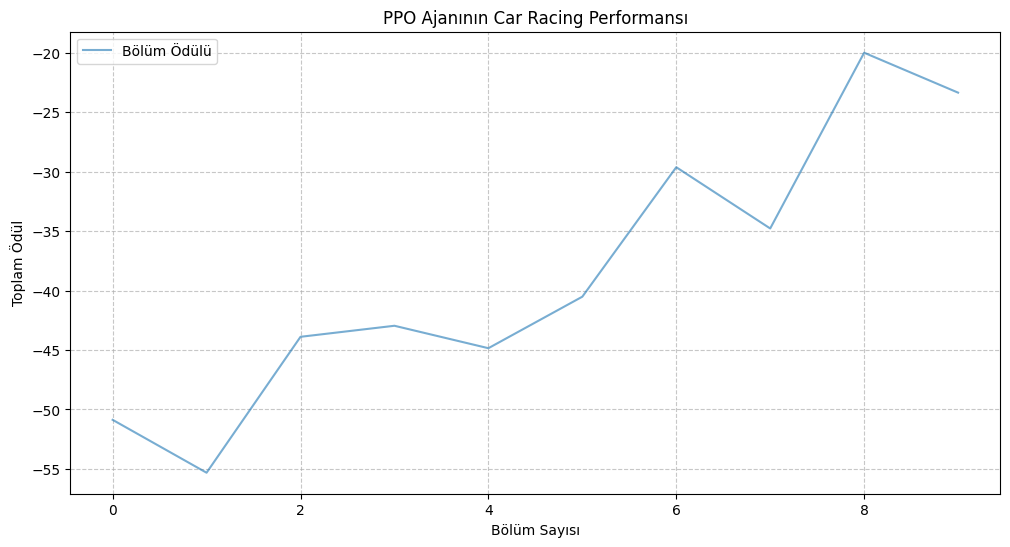

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(ppo_logger.episode_rewards, label='Bölüm Ödülü', color='#1f77b4', alpha=0.6)

# Hareketli ortalama alarak trendi daha net görelim (opsiyonel)
if len(ppo_logger.episode_rewards) > 10:
    yields = np.convolve(ppo_logger.episode_rewards, np.ones(10)/10, mode='valid')
    plt.plot(yields, label='10 Bölümlük Ortalama', color='red', linewidth=2)

plt.title('PPO Ajanının Car Racing Performansı')
plt.xlabel('Bölüm Sayısı')
plt.ylabel('Toplam Ödül')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### 📊 Politika Gradyanı Eğitim Günlüğü Metriklerini Anlama

PPO gibi algoritmalarla eğitim yaparken, çeşitli günlük metrikleri performansı ve eğitim kararlılığını takip etmenize yardımcı olur.

#### ⏱️ Zamanla İlgili Metrikler

- **fps** → Saniye başına kare — model ne kadar hızlı eğitiliyor. Yüksek = daha iyi.  
- **iterations** → Tamamlanan parametre güncelleme döngüsü sayısı.  
- **time_elapsed** → Eğitimin başlamasından bu yana geçen toplam süre (saniye).  
- **total_timesteps** → Ajan tarafından deneyimlenen toplam ortam adımı sayısı.

#### 🧠 Eğitim Süreci Metrikleri

- **approx_kl** → Bir güncellemeden sonra politikanın ne kadar değiştiği.  
  - Düşük = daha kararlı öğrenme.  
- **clip_fraction** → PPO'nun güncelleme kırpmasının ne sıklıkta uygulandığı.  
- **clip_range** → Politika güncellemelerini kırpmak için kullanılan aralık (ani değişiklikleri önler).  
- **entropy_loss** → Eylem seçimindeki rastgeleliği ölçer.  
  - Yüksek = daha fazla keşif.  
- **explained_variance** → Değer tahminlerinin gerçek getirilerle ne kadar eşleştiği.  
  - 1'e yakın = daha iyi.  
- **learning_rate** → Ağırlık güncellemelerinin boyutunu kontrol eder.  
- **loss** → Genel eğitim kaybı — iyileşmeyi takip etmeye yardımcı olur.  
- **n_updates** → Toplam model ağırlığı güncellemesi sayısı.  
- **policy_gradient_loss** → Politikanın ne kadar iyileştiğini gösterir.  
- **value_loss** → Değer fonksiyonu tahminlerinin ne kadar doğru olduğunu ölçer.

#### 🔍 Bu Metrikleri Nasıl Yorumlarız

- **Yüksek `entropy_loss`** → Ajan daha fazla keşfediyor (çok rastgele olabilir).  
- **Düşük `explained_variance`** → Değer tahminleri yanlış.  
- **Azalan `loss`** → Zaman içinde etkili öğrenme olduğunu gösterir.

---

### 🧠 Politika Gradyanı Neden CarRacing için İdeal

CarRacing pürüzsüz ve hassas kontrol gerektirir — bu da **Politika Gradyanı yöntemleri** olan **PPO**'yu mükemmel uyum haline getirir.

#### 1. 🎯 Sürekli Eylemler için Tasarlandı  
- PPO **gerçek değerli eylemleri** doğrudan işler.  
- CarRacing'de, ajan sadece sol veya sağı seçmek değil, *ne kadar direksiyon kırılacağını*, *ne kadar sert fren yapılacağını* ve *ne kadar gaz verileceğini* seçmesi gerekir.

#### 2. 🧠 Politikayı Doğrudan Öğrenir  
- Eylemlerin değerini tahmin eden DQN'un aksine, PPO *nasıl* davranacağını öğrenir.  
- Bu, yüksek hızlı sürüş ortamlarında kritik olan **daha esnek ve uyarlanabilir davranışlara** olanak tanır.

#### 3. 🪶 Pürüzsüz ve Hassas Kontrol  
- PPO **ince ayarlı kararları** destekler — sürüş görevlerinde gereken ince ayarlamalar için mükemmel.  
- Artık ani, hep ya da hiç hareketler yok.

---

### ❌ DQN Neden Burada İyi Bir Uyum Değil

- **DQN ayrık eylem uzayı gerektirir** (ör. *yukarı*, *aşağı*, *sol*, *sağ*).  
- CarRacing **sürekli eylem uzayı** kullanır — eylemlerin gerçel sayılar olduğu.

DQN kullanmak için, direksiyon/fren/gaz kombinasyonlarının tamamını **ayrıklaştırmanız** gerekir:  
🧱 Verimsiz ve nadiren etkili olan bir geçici çözüm.

---

### ⚖️ Özet: Politika Gradyanının Parladığı Yer Burası

| Yöntem           | CarRacing'deki Gücü                                    |
|------------------|-----------------------------------------------------------|
| 🧠 Politika Gradyanı | Sürekli eylemleri doğrudan öğrenir — ayrıklaştırma gerekmez. |
| ❌ DQN             | Sürekli eylemler için inşa edilmemiş — uyum sağlamakta zorlanır.         |